# Snake Detection - YOLOv8 Inference & Evaluation
Notebook này dùng để test mô hình đã train và vẽ biểu đồ quá trình huấn luyện.

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import random
import glob
import cv2
from PIL import Image

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


---
## 1. Load model đã train

In [2]:
model = YOLO('runs/detect/train/weights/best.pt')
print(f'Parameters: {sum(p.numel() for p in model.model.parameters()):,}')
print(f'Classes ({len(model.names)}): {list(model.names.values())}')

Parameters: 3,015,333
Classes (23): ['Banded_krait', 'Burmese_python', 'Common_sunbeam_snake', 'Copperhead_racer', 'Golden_tree_snake', 'Indochinese_rat_snake', 'Javan_wart_snake', 'King_cobra', 'Laotian_wolf_snake', 'Large_eyed_pit_viper', 'Malayan_krait', 'Malayan_pit_viper', 'Monocled_cobra', 'Oriental_rat_snake', 'Rainbow_mud_snake', 'Reticulated_python', 'Siamese_Russell-s_Viper', 'Siamese_red_necked_keelback', 'Small_banded_kukri_snake', 'Small_spotted_coral_snake', 'Striped_kukri_snake', 'Western_mangrove_cat_snake', 'Yellow_spotted_keelback']


---
## 2. Biểu đồ quá trình huấn luyện

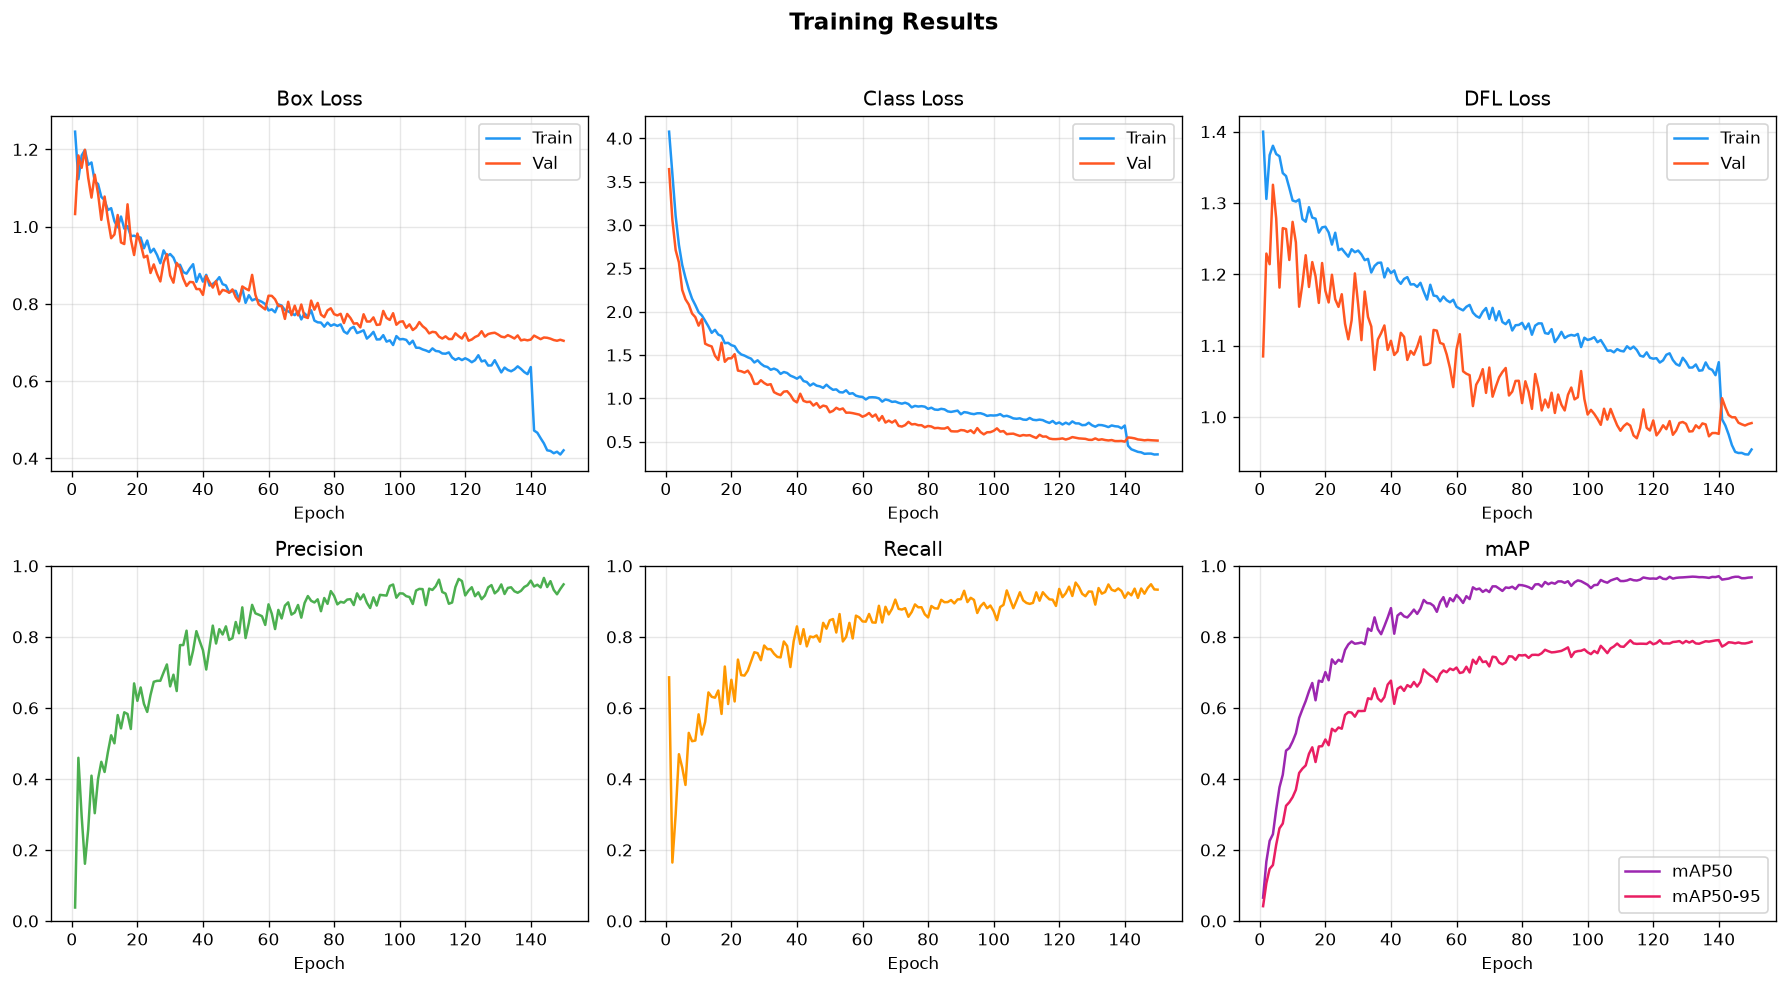

Best epoch: 140 | mAP50: 0.9708 | mAP50-95: 0.7910


In [3]:
df = pd.read_csv('runs/detect/train/results.csv')
df.columns = df.columns.str.strip()
epochs = df['epoch']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Training Results', fontsize=14, fontweight='bold', y=1.02)

axes[0, 0].plot(epochs, df['train/box_loss'], label='Train', color='#2196F3')
axes[0, 0].plot(epochs, df['val/box_loss'], label='Val', color='#FF5722')
axes[0, 0].set_title('Box Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, df['train/cls_loss'], label='Train', color='#2196F3')
axes[0, 1].plot(epochs, df['val/cls_loss'], label='Val', color='#FF5722')
axes[0, 1].set_title('Class Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(epochs, df['train/dfl_loss'], label='Train', color='#2196F3')
axes[0, 2].plot(epochs, df['val/dfl_loss'], label='Val', color='#FF5722')
axes[0, 2].set_title('DFL Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, df['metrics/precision(B)'], color='#4CAF50')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, df['metrics/recall(B)'], color='#FF9800')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(epochs, df['metrics/mAP50(B)'], label='mAP50', color='#9C27B0')
axes[1, 2].plot(epochs, df['metrics/mAP50-95(B)'], label='mAP50-95', color='#E91E63')
axes[1, 2].set_title('mAP')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = df.loc[df['metrics/mAP50-95(B)'].idxmax(), 'epoch']
best_map50 = df['metrics/mAP50(B)'].max()
best_map50_95 = df['metrics/mAP50-95(B)'].max()
print(f'Best epoch: {int(best_epoch)} | mAP50: {best_map50:.4f} | mAP50-95: {best_map50_95:.4f}')

---
## 3. Test trên ảnh đơn lẻ

Tổng số ảnh test: 204

image 1/1 /home/huy/Source/AI_detect_snake_entering_home/dataset/test/images/259829209_1360296051031834_8451572150877142193_n-removebg-preview_png.rf.fc1629b5b3e0458a28b45af089570cde.jpg: 256x256 1 Siamese_red_necked_keelback, 11.6ms
Speed: 2.8ms preprocess, 11.6ms inference, 24.0ms postprocess per image at shape (1, 3, 256, 256)


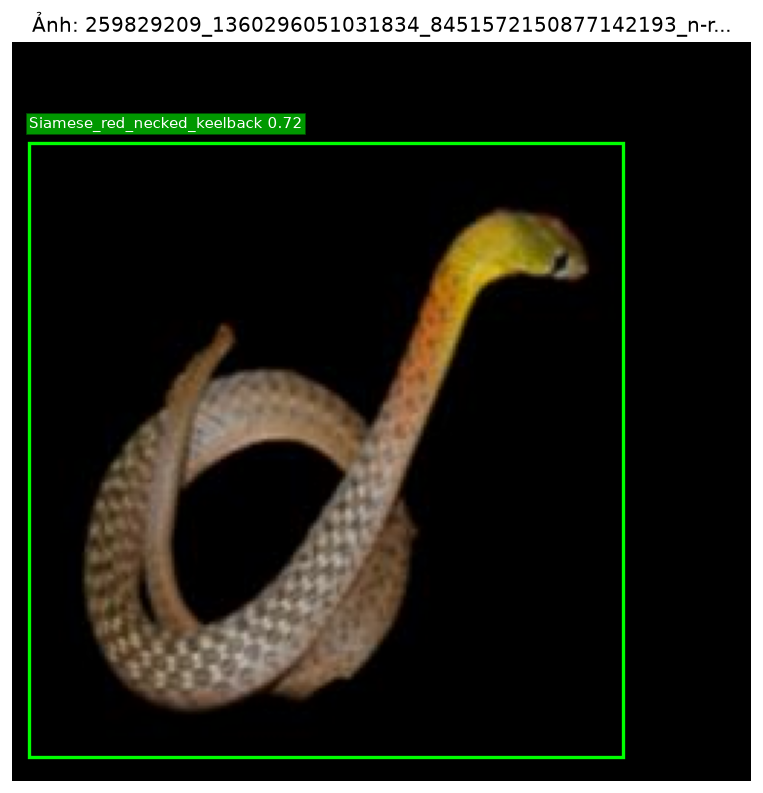

Phát hiện: 1 object(s)


In [4]:
test_images = sorted(glob.glob('dataset/test/images/*'))
print(f'Tổng số ảnh test: {len(test_images)}')

img_path = random.choice(test_images)
results = model(img_path, conf=0.25)[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img)

for box in results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = box.conf[0].item()
    cls_id = int(box.cls[0].item())
    label = f'{model.names[cls_id]} {conf:.2f}'
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=2, edgecolor='#00FF00', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, label, color='white', fontsize=9,
            bbox=dict(facecolor='#00FF00', alpha=0.6, pad=2))

ax.axis('off')
plt.title(f'Ảnh: {img_path.split("/")[-1][:50]}...')
plt.show()
print(f'Phát hiện: {len(results.boxes)} object(s)')

---
## 4. Test trên grid nhiều ảnh


0: 256x256 1 Common_sunbeam_snake, 19.1ms
1: 256x256 1 Golden_tree_snake, 19.1ms
2: 256x256 1 Common_sunbeam_snake, 19.1ms
3: 256x256 1 Monocled_cobra, 19.1ms
4: 256x256 1 Siamese_red_necked_keelback, 19.1ms
5: 256x256 1 Striped_kukri_snake, 19.1ms
6: 256x256 1 King_cobra, 19.1ms
7: 256x256 1 Laotian_wolf_snake, 19.1ms
8: 256x256 1 Reticulated_python, 19.1ms
Speed: 2.0ms preprocess, 19.1ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 256)


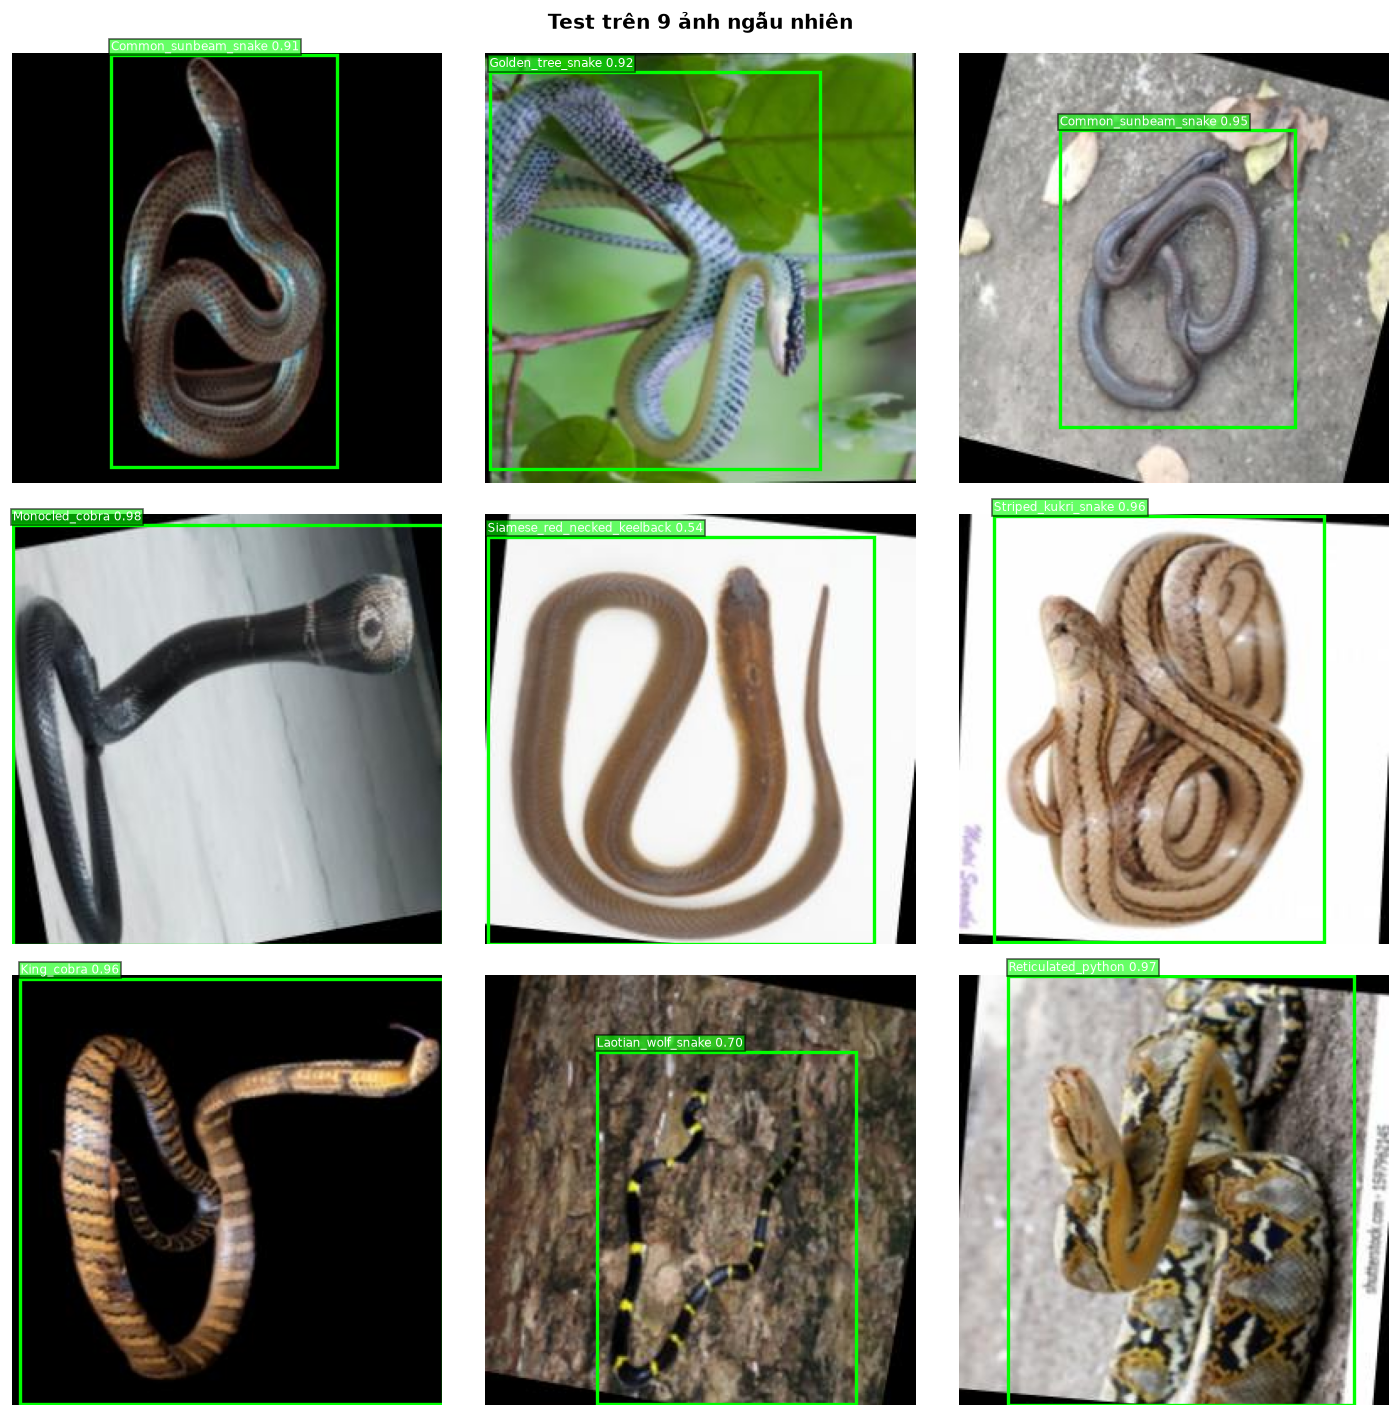

In [5]:
sample_imgs = random.sample(test_images, min(9, len(test_images)))
results = model(sample_imgs, conf=0.25)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, (result, ax) in enumerate(zip(results, axes.flat)):
    img = cv2.imread(sample_imgs[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        label = f'{model.names[cls_id]} {conf:.2f}'
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='#00FF00', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-3, label, color='white', fontsize=7,
                bbox=dict(facecolor='#00FF00', alpha=0.6, pad=1))

    ax.axis('off')

plt.suptitle(f'Test trên {len(sample_imgs)} ảnh ngẫu nhiên', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Validation trên tập test

In [6]:
metrics = model.val(data='data.yaml', split='test', conf=0.25, iou=0.5)

print('Kết quả trên tập test:')
print(f'  Precision: {metrics.box.mp:.4f}')
print(f'  Recall:    {metrics.box.mr:.4f}')
print(f'  mAP50:     {metrics.box.map50:.4f}')
print(f'  mAP50-95:  {metrics.box.map:.4f}')

Ultralytics 8.4.96 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 357.2±129.9 MB/s, size: 13.0 KB)
val: Scanning /home/huy/Source/AI_detect_snake_entering_home/dataset/test/labels.cache... 204 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 204/204 14.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.9it/s 4.5s0.1s
                   all        204        205       0.91      0.947      0.934      0.773
          Banded_krait          7          7          1          1      0.995      0.825
        Burmese_python         16         16          1          1      0.995      0.873
  Common_sunbeam_snake         10         10          1          1      0.995      0.878
      Copperhead_racer          4          4          1          1      0.995      0.852
     Golden_tree_snake          8          8          1       0.7

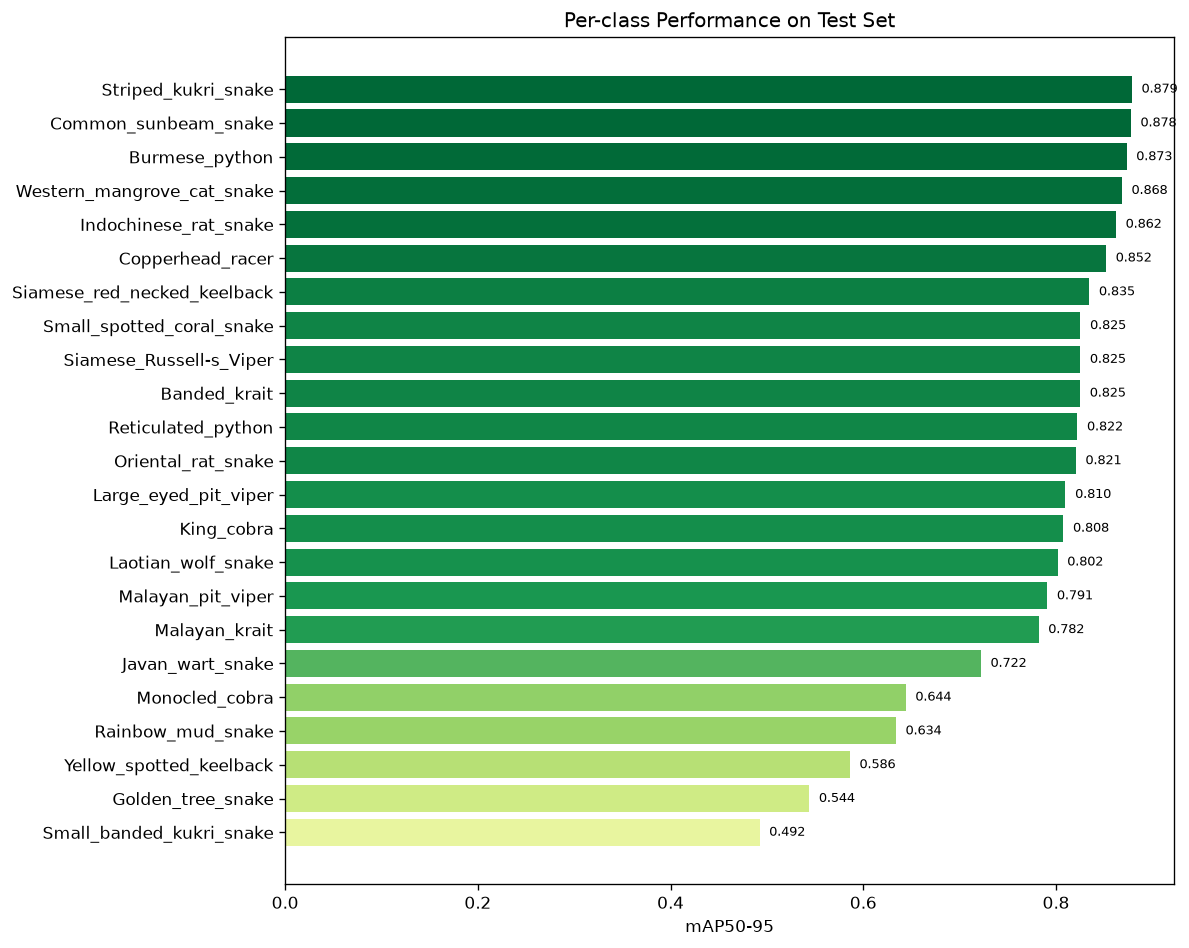

In [7]:
ap_per_class = metrics.box.ap
class_names = list(model.names.values())

perf = pd.DataFrame({
    'Class': class_names,
    'mAP50-95': [round(x, 4) for x in ap_per_class]
}).sort_values('mAP50-95', ascending=False).reset_index(drop=True)
perf.index = perf.index + 1

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(perf['mAP50-95'] / perf['mAP50-95'].max())
bars = ax.barh(range(len(perf)), perf['mAP50-95'], color=colors)
ax.set_yticks(range(len(perf)))
ax.set_yticklabels(perf['Class'])
ax.set_xlabel('mAP50-95')
ax.set_title('Per-class Performance on Test Set')
ax.invert_yaxis()

for bar, val in zip(bars, perf['mAP50-95']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()